# Setup

In [2]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
import logging
import tpvalidator.workspace as workspace
import tpvalidator.analyzers.snn as snn

from rich import print
from tpvalidator.utils import temporary_log_level, pandas_backend

from collections import OrderedDict

# Code

In [4]:
from rich import box
from rich.table import Table
from typing import Optional, Dict

def df_to_table(
    pandas_dataframe: pd.DataFrame,
    show_index: bool = True,
    index_name: Optional[str] = None,
    formatters: Optional[Dict[str,str]] = {},
    **kwargs
) -> Table:
    """Convert a pandas.DataFrame obj into a rich.Table obj.
    Args:
        pandas_dataframe (DataFrame): A Pandas DataFrame to be converted to a rich Table.
        rich_table (Table): A rich Table that should be populated by the DataFrame values.
        show_index (bool): Add a column with a row count to the table. Defaults to True.
        index_name (str, optional): The column name to give to the index column. Defaults to None, showing no value.
    Returns:
        Table: The rich Table instance passed, populated with the DataFrame values."""
    rich_table = Table(**kwargs)
    if show_index:
        index_name = str(index_name) if index_name else ""
        rich_table.add_column(index_name)

    for column in pandas_dataframe.columns:
        rich_table.add_column(str(column))

    for row in pandas_dataframe.itertuples():
        t_row = [str(row[0])] if show_index else []
        r = row._asdict()
        for c in pandas_dataframe.columns:
            fmt = formatters.get(c,'{}')
            t_row.append(fmt.format(r[c]))
        rich_table.add_row(*t_row)

    #     rich_table.add_row(*row)

    return rich_table

In [5]:
from typing import Tuple, Optional, Union, Sequence, Dict, List
from rich.table import Table
from tpvalidator.detector_geometry import FDVDGeometry_1x8x6


def make_rates_table_from_workspaces( 
        datasets : Dict[str,workspace.TriggerPrimitivesWorkspace], 
        preselection: str = '', 
        per:str='chan', 
        ro_win_len: int=None) -> pd.DataFrame:
    """
    Calculates the TP rates of each workspace in the dataset list.
    The rate is calculated over the chosen unit specified by the `per` argument: channel, crp, tpc or detector.
    The rates are displayed per unit and per view.

    If a preselection is specified, this is applied to all datasets before the rate calculation.
    The readout window lenght, needed for the rate estimate, is passed as argument.
    """
    
    # Constants : move them somewhere else
    sampling_period = 0.5e-6

    num_el_map = {
        'chan' : lambda v: FDVDGeometry_1x8x6.crp_num_chans_by_view_sim(v)*FDVDGeometry_1x8x6.num_crps,
        'crp' : lambda _: FDVDGeometry_1x8x6.num_crps,
        'tpc' : lambda _: FDVDGeometry_1x8x6.num_tpcs,
        'det' : lambda _: 1,
    }
    
    num_el = num_el_map[per]

    rows=[]
    for s, ws in datasets.items():
        num_ev = ws.num_entries
        # Throw if not available
        ro_win_len = ws._extra_info['readout_window'] if ro_win_len is None else ro_win_len

        total_time = num_ev*ro_win_len*sampling_period 
        tps_sel = ws.tps.query(preselection) if preselection else ws.tps
        tp_rates = []
        for v in range(3):
            num_els = num_el(v)
            tp_rate = len(tps_sel.query(f'readout_view == {v}'))/total_time/num_els
            tp_rates += [tp_rate]
        rows += [(s, total_time, *tp_rates)]

    df = pd.DataFrame(
        np.array(rows, dtype=[("dataset",object), ("time",float), ("U",float), ("V",float), ("X",float)]),
        columns=['dataset','time', 'U', 'V', 'X']
    )

    return df

In [6]:
def make_vd_rates_table_2(datasets : Dict[str,pd.DataFrame], num_events, preselection: str = '', per:str='chan', title: str='', ro_win_len: int=None, sampling_period=5e-6) -> Table:

    num_el_map = {
        'chan' : lambda v: FDVDGeometry_1x8x6.crp_num_chans_by_view_sim(v)*FDVDGeometry_1x8x6.num_crps,
        'crp' : lambda _: FDVDGeometry_1x8x6.num_crps,
        'tpc' : lambda _: FDVDGeometry_1x8x6.num_tpcs,
        'det' : lambda _: 1,
    }

    num_el = num_el_map[per]

    t = Table('sample', 'time', 'U', 'V', 'X', title=title)
    for s, df in datasets.items():
        num_ev = num_events
        
        # Throw if not available
        ro_win_len = df.extra_info['readout_window'] if ro_win_len is None else ro_win_len

        total_time = num_ev*ro_win_len*sampling_period
        row = [s, f'{total_time:.3f} s']
        tps_sel = df.query(preselection) if preselection else df
        for v in range(3):
            num_els = num_el(v)
            noise_rate = len(tps_sel.query(f'readout_view == {v}'))/total_time/num_els
            row += [f'{noise_rate:.2f} Hz']
        t.add_row(*row)
    return t

# Data

In [7]:
dataset_info = {
    'readout_window' : 8500
}



from pathlib import Path
pre_prod_dir = Path('../../data/vd/pre_prod/')


with temporary_log_level(workspace.TriggerPrimitivesWorkspace._log, logging.WARN):
    rad_ws = workspace.TriggerPrimitivesWorkspace(pre_prod_dir / 'anatree_vd_radiols_hist.root', extra_info=dataset_info)
rad_ws.add_rawdigits(pre_prod_dir / 'rawdigits' / 'trigger_digits_hists_detsim_vd_radiols.root')

print(rad_ws.info)


datasets = {
    # 'e-minus': em_ws,
    # 'gamma': gm_ws,
    # 'mu-minus': mu_ws,
    # 'ar39': ar39_ws,
    'radiols': rad_ws
}


{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [8]:
# Sanitize TPs
# This cut removes TPs in regions where the sim/backtracking response is ambiguous :
# - sample_peak < 100 : reduced backtracking efficiency
# - sample_peak > 8100 : missing ides
wirecell_ides_cut = 'sample_peak > 100 & sample_peak < 8100'

for n, ws in datasets.items():
    ws.tps.query(wirecell_ides_cut, inplace=True)
    ws.tps.extra_info['readout_window'] = 8000

In [9]:
t = Table('generator name', 'id', title="Background generators")
for gid, n in rad_ws.mctruth_blocks_map.items():
    t.add_row(n, str(gid))

print(t)


             Background generators             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━┓
┃ generator name                         ┃ id ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━┩
│ Rn222ChainBi214GenInLAr                │ 1  │
│ Rn222ChainFromBi214GenInUpperMesh1x8x6 │ 2  │
│ Th232ChainGenInAnode                   │ 3  │
│ CavernwallGammasAtLAr1x8x6             │ 4  │
│ Rn222ChainFromPb210GenInUpperMesh1x8x6 │ 5  │
│ Rn222ChainFromPb214GenInUpperMesh1x8x6 │ 6  │
│ Rn222ChainPo218GenInLAr                │ 7  │
│ Rn222ChainPb214GenInLAr                │ 8  │
│ Ar39GenInLAr                           │ 9  │
│ Rn222ChainPb210GenInLAr                │ 10 │
│ Rn222ChainFromBi210GenInUpperMesh1x8x6 │ 12 │
│ Ar42GenInLAr                           │ 13 │
│ Rn222ChainGenInPDS                     │ 14 │
│ Rn220ChainPb212GenInLAr                │ 16 │
│ K40GenInAnode                          │ 18 │
│ U238ChainGenInCathode                  │ 19 │
│ Rn222ChainRn222GenInLAr                │ 20 │
│ Th232ChainGenInCathode                 │ 21 │
│ K42From42ArGenInUpperMesh1x8x6         │ 22 │
│ foamGammasAtLAr1x8x6                   │ 23 │
│ K40GenInCathode                        │ 24 │
│ U238ChainGenInAnode                    │ 25 │
│ Kr85GenInLAr                           │ 26 │
│ Rn220ChainFromPb212GenInUpperMesh1x8x6 │ 28 │
│ Rn222ChainFromPo218GenInUpperMesh1x8x6 │ 11 │
│ CavernNGammasAtLAr1x8x6                │ 0  │
│ K42From42ArGenInLAr                    │ 15 │
│ CavernwallNeutronsAtLAr1x8x6           │ 17 │
│ CryostatNGammasAtLAr1x8x6              │ 27 │
└────────────────────────────────────────┴────┘

In [10]:

simulated_time = 8500e-6*100

t = Table('generator name', 'entries', 'rate [Hz]', title="Backgrounds generators by activity")
part_by_gen = sorted([(n,df) for n,df in rad_ws.mctruths.groupby('generator_name')], reverse=True, key=lambda x: len(x[1]))
for gen_id, df in part_by_gen:
    t.add_row(gen_id, str(len(df)), f'{len(df)/simulated_time:.2f}')
print(t)

               Backgrounds generators by activity                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ generator name                         ┃ entries ┃ rate [Hz]  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x6             │ 5100989 │ 6001163.53 │
│ Ar39GenInLAr                           │ 1497383 │ 1761627.06 │
│ foamGammasAtLAr1x8x6                   │ 214119  │ 251904.71  │
│ Kr85GenInLAr                           │ 170497  │ 200584.71  │
│ Th232ChainGenInCathode                 │ 154128  │ 181327.06  │
│ U238ChainGenInCathode                  │ 129649  │ 152528.24  │
│ Th232ChainGenInAnode                   │ 69370   │ 81611.76   │
│ U238ChainGenInAnode                    │ 58311   │ 68601.18   │
│ K40GenInCathode                        │ 10021   │ 11789.41   │
│ K40GenInAnode                          │ 4572    │ 5378.82    │
│ Rn222ChainFromBi214GenInUpperMesh1x8x6 │ 2431    │ 2860.00    │
│ Rn222ChainFromPb210GenInUpperMesh1x8x6 │ 2397    │ 2820.00    │
│ Rn222ChainPb214GenInLAr                │ 2392    │ 2814.12    │
│ Rn222ChainBi214GenInLAr                │ 2294    │ 2698.82    │
│ Rn220ChainFromPb212GenInUpperMesh1x8x6 │ 2238    │ 2632.94    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x6 │ 1742    │ 2049.41    │
│ Rn222ChainRn222GenInLAr                │ 1539    │ 1810.59    │
│ Rn222ChainPo218GenInLAr                │ 1318    │ 1550.59    │
│ Rn220ChainPb212GenInLAr                │ 1263    │ 1485.88    │
│ Rn222ChainPb210GenInLAr                │ 1022    │ 1202.35    │
│ Rn222ChainFromPb214GenInUpperMesh1x8x6 │ 950     │ 1117.65    │
│ Ar42GenInLAr                           │ 140     │ 164.71     │
│ K42From42ArGenInUpperMesh1x8x6         │ 123     │ 144.71     │
│ Rn222ChainFromPo218GenInUpperMesh1x8x6 │ 94      │ 110.59     │
│ Rn222ChainGenInPDS                     │ 56      │ 65.88      │
│ K42From42ArGenInLAr                    │ 23      │ 27.06      │
│ CryostatNGammasAtLAr1x8x6              │ 7       │ 8.24       │
│ CavernNGammasAtLAr1x8x6                │ 1       │ 1.18       │
│ CavernwallNeutronsAtLAr1x8x6           │ 1       │ 1.18       │
└────────────────────────────────────────┴─────────┴────────────┘

# MC particles spectra

This is useful to tell the expected energy of clusters from background

Text(0.5, 1.0, 'MCParticles (G4)')

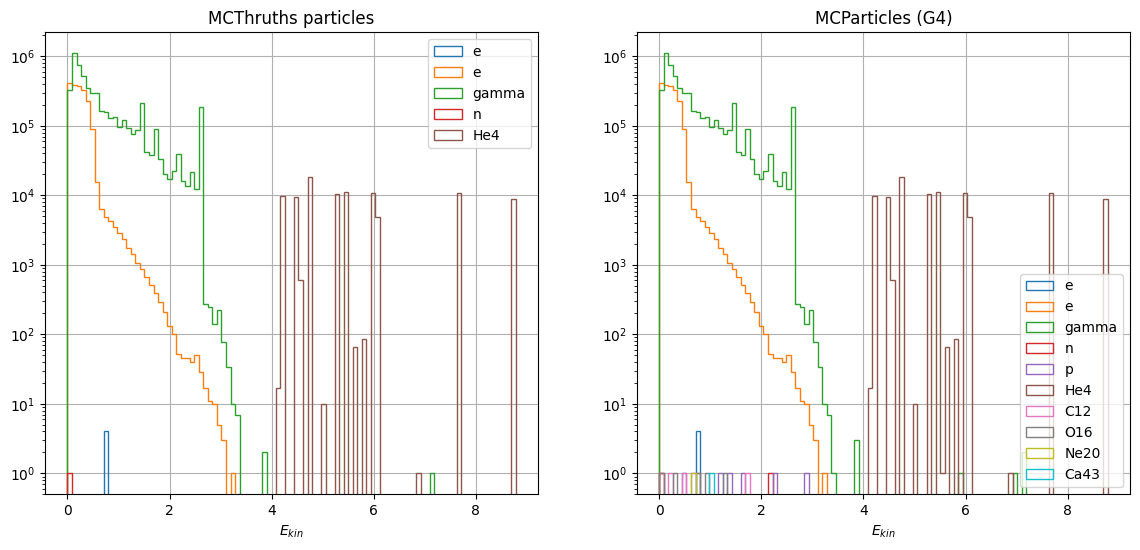

In [11]:
import particle

mct = datasets['radiols'].mctruths
mcp = datasets['radiols'].mcparticles
max_ke=max(mct.kinetic_energy.max(), mcp.kinetic_energy.max())

all_pdgs = np.union1d(mct.pdg.unique(), mcp.pdg.unique())
colors = plt.cm.tab10.colors 
color_map = {pdg: colors[i % len(colors)] for i, pdg in enumerate(all_pdgs)}

bins=np.linspace(0,max_ke*1000,100)
fig,axes=plt.subplots(1,2, figsize=(14,6))

ax=axes[0]
for pdg_id, df in mct.groupby('pdg'):
    pp = particle.Particle.from_pdgid(pdg_id)
    (df.kinetic_energy*1000).hist(bins=bins, label=f"{pp.pdg_name}", histtype='step', color=color_map[pdg_id], ax=ax)

ax.legend()
ax.set_yscale('log')
ax.set_xlabel(r'$E_{kin}$')
ax.set_title('MCThruths particles')


ax=axes[1]
for pdg_id, df in mcp.groupby('pdg'):
    pp = particle.Particle.from_pdgid(pdg_id)
    (df.kinetic_energy*1000).hist(bins=bins, label=f"{pp.pdg_name}", histtype='step', color=color_map[pdg_id], ax=ax)

ax.legend()
ax.set_yscale('log')
ax.set_xlabel(r'$E_{kin}$')
ax.set_title('MCParticles (G4)')




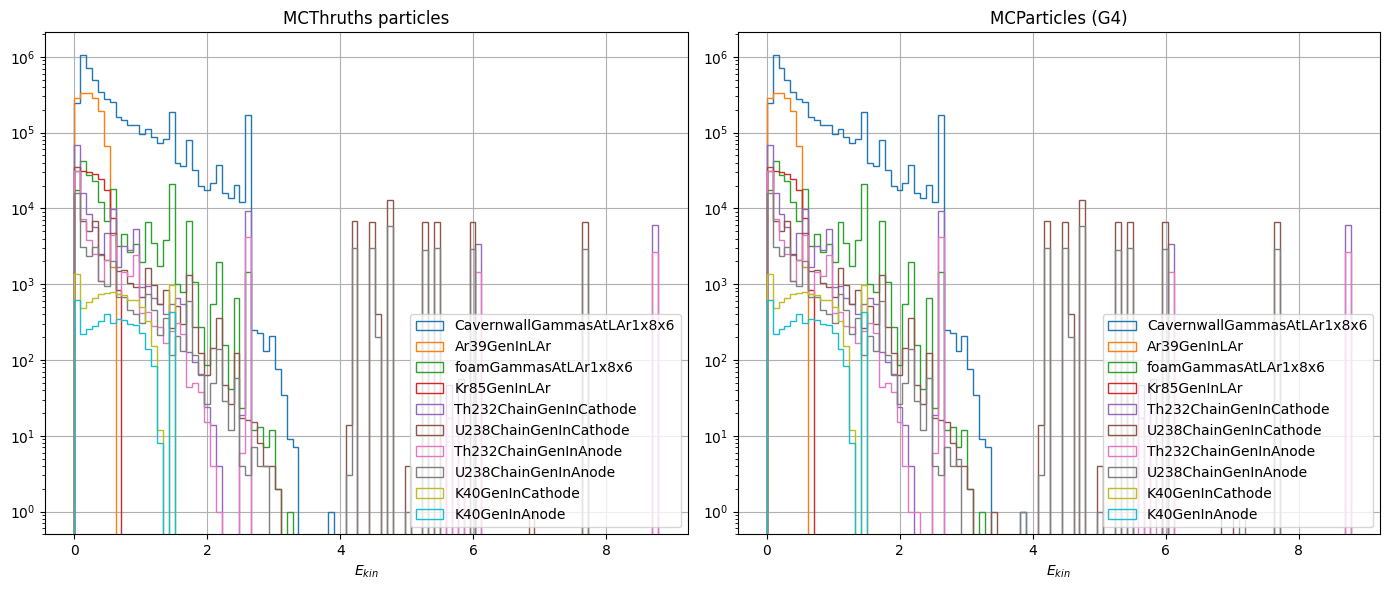

In [12]:

mct = datasets['radiols'].mctruths
mcp = datasets['radiols'].mcparticles
mct_block_map = datasets['radiols'].mctruth_blocks_map

max_ke=max(mct.kinetic_energy.max(), mcp.kinetic_energy.max())

num_bkg=10
part_by_gen = sorted([(n,df) for n,df in mct.groupby('generator_name')], reverse=True, key=lambda x: len(x[1]))
top_by_gen = part_by_gen[:num_bkg]

all_gens = mct.generator_name.unique()
colors = plt.cm.tab20.colors 
color_map = {pdg: colors[i % len(colors)] for i, pdg in enumerate(all_gens)}


# I want to move from rates to counts, which means dividing counts by the elapsed time.
# The elapsed time num events * emulation window = 100*2*4.25e-6
bins=np.linspace(0,max_ke*1000,100)
fig,axes=plt.subplots(1,2, figsize=(14,6))

ax=axes[0]
for gen_id, df in top_by_gen:
    (df.kinetic_energy*1000).hist(bins=bins, label=f"{gen_id}", histtype='step', ax=ax)

ax.legend()
ax.set_yscale('log')
ax.set_xlabel(r'$E_{kin}$')
ax.set_title('MCThruths particles')


part_by_gen = sorted([(mct_block_map[n],df) for n,df in mcp.groupby('truth_block_id')], reverse=True, key=lambda x: len(x[1]))
top_by_gen = part_by_gen[:num_bkg]


ax=axes[1]
for gen_id, df in top_by_gen:

    (df.kinetic_energy*1000).hist(bins=bins, label=f"{gen_id}", histtype='step', ax=ax)

ax.legend()
ax.set_yscale('log')
ax.set_xlabel(r'$E_{kin}$')
ax.set_title('MCParticles (G4)')

fig.tight_layout()



/var/folders/dw/sj94s2457kl2gkb829ty4_cc0000gn/T/ipykernel_58057/2501421283.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation='vertical')


Text(0.5, 0.98, 'Radioactive backgrounds producing $e^{-}$')

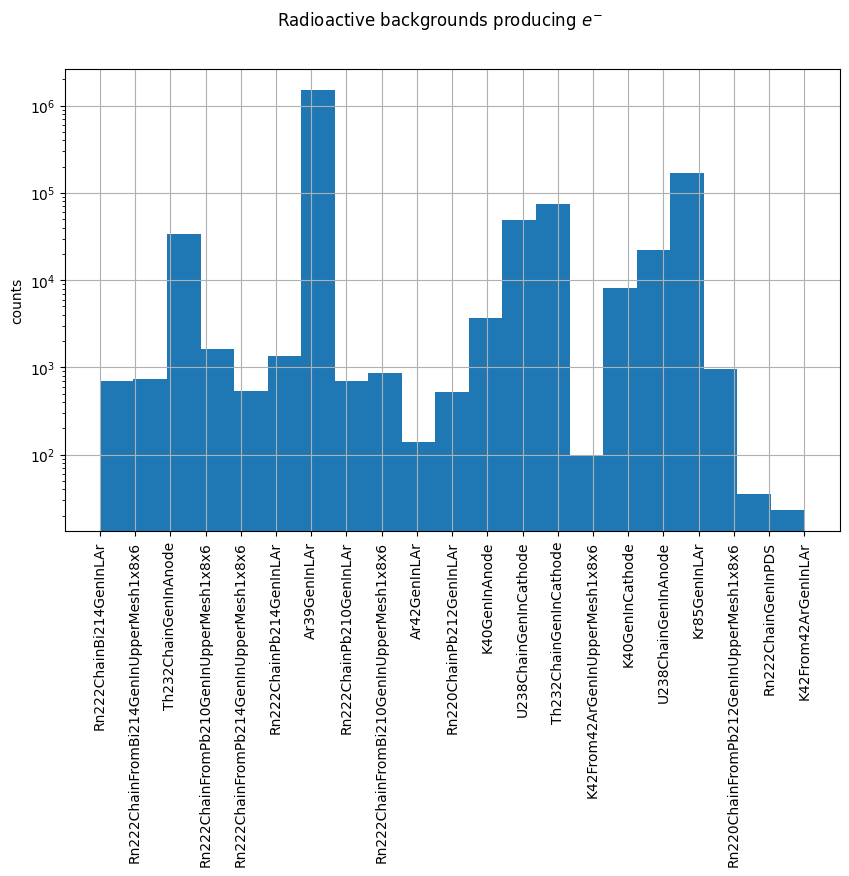

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
n_bins = datasets['radiols'].mctruths.query("pdg == 11").generator_name.nunique()
datasets['radiols'].mctruths.query("pdg == 11").generator_name.hist(bins=n_bins, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation='vertical')
ax.set_ylabel('counts')
ax.set_yscale('log')
fig.suptitle("Radioactive backgrounds producing $e^{-}$")



<Axes: >

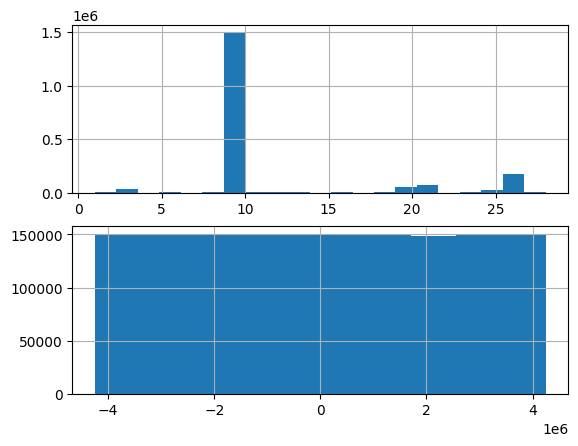

In [14]:
fig, axes = plt.subplots(2,1)
n_bins = datasets['radiols'].mcparticles.query("pdg == 11").truth_block_id.nunique()
datasets['radiols'].mcparticles.query("pdg == 11").truth_block_id.hist(bins=n_bins, ax=axes[0])


datasets['radiols'].mcparticles.query('truth_block_id == 9').t.hist(ax=axes[1])

# TP Spectra, by generator

In [15]:
# Create a TP preselection - only TPs with peak within the range where backtracking works

rad_sel = snn.TPSignalNoiseSelector(rad_ws.tps)

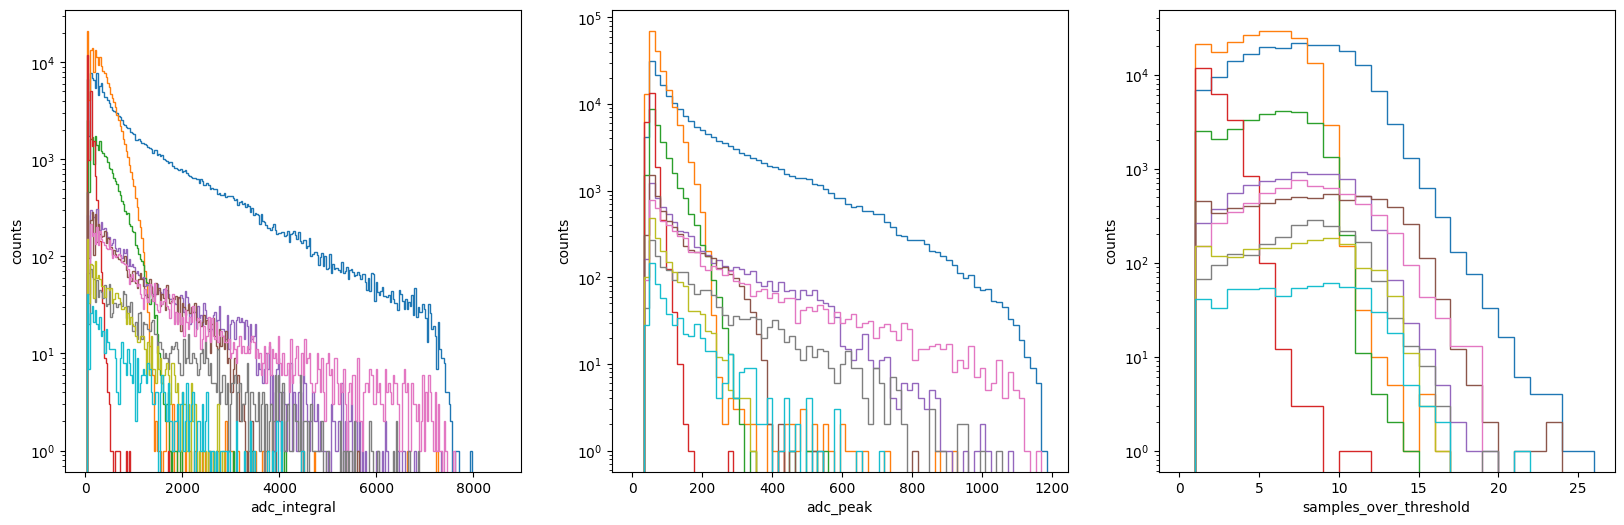

In [16]:
# Plot rates distributions for the top backgrounds

def plot_tpcounts_by_source(tps, ax, var='adc_integral', binsize=8):

    num_bkg = 10
    tps_by_gen = sorted([(n,df) for n,df in tps.groupby('bt_generator_name')], reverse=True, key=lambda x: len(x[1]))
    top_by_gen = tps_by_gen[:num_bkg]

    bin_max = max([df[var].max() for _, df in top_by_gen])

    bins=np.arange(0, int(bin_max), binsize)

    for n,df in top_by_gen:
        ax.hist(df[var], bins=bins, histtype='step', label=n if n else 'noise')
    # ax.legend()
    ax.set_yscale('log')
    ax.set_xlabel(var)
    ax.set_ylabel('counts')


fig, axes = plt.subplots(1,3, figsize=(20,6))
ro_view = 2

ax = axes[0]
plot_tpcounts_by_source(rad_sel.all_by_view[ro_view], var='adc_integral', binsize=32, ax =ax)
ax = axes[1]
plot_tpcounts_by_source(rad_sel.all_by_view[ro_view], var='adc_peak', binsize=16, ax =ax)
ax = axes[2]
plot_tpcounts_by_source(rad_sel.all_by_view[ro_view], var='samples_over_threshold', binsize=1, ax =ax)


# fig, axes = plt.subplots(1,3, figsize=(20,6))
# ro_view = 2
# sot_thres = 7

# ax = axes[0]
# plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query(f'samples_over_threshold > {sot_thres}'), var='adc_integral', binsize=64, ax =ax)
# ax = axes[1]
# plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query(f'samples_over_threshold > {sot_thres}'), var='adc_peak', binsize=16, ax =ax)
# ax = axes[2]
# plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query(f'samples_over_threshold > {sot_thres}'), var='samples_over_threshold', binsize=1, ax =ax)

# fig = plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query('samples_over_threshold > 8')f, var=var, binsize=32)
# var = 'adc_peak'
# fig = plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query('samples_over_threshold > 8'), var=var, binsize=16)
# var = 'samples_over_threshold'
# fig = plot_tpcounts_by_source(rad_sel.all_by_view[ro_view].query('samples_over_threshold > 8'), var=var, binsize=1)


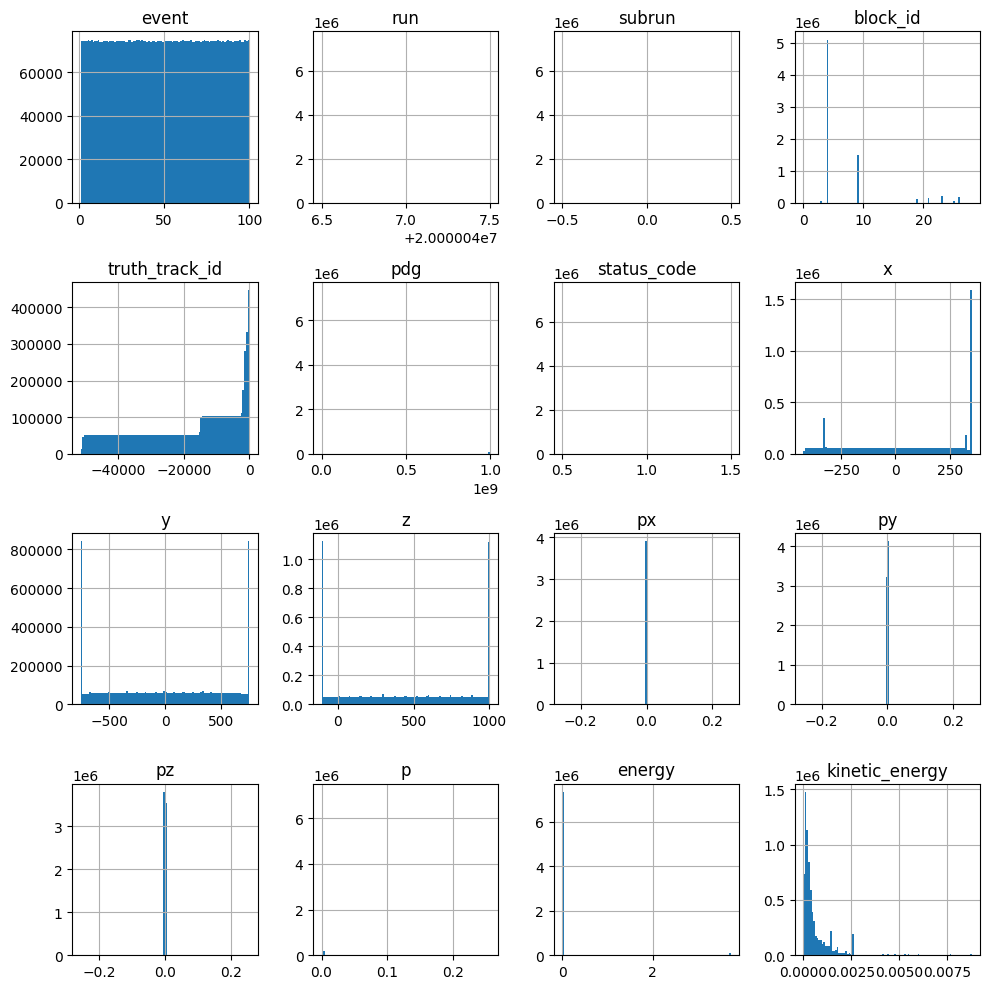

In [20]:
mct.hist(figsize=(10,10), bins=100)
plt.gcf().tight_layout()

# Wall gammas origin checks

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'y'}>],
       [<Axes: title={'center': 'z'}>, <Axes: >]], dtype=object)

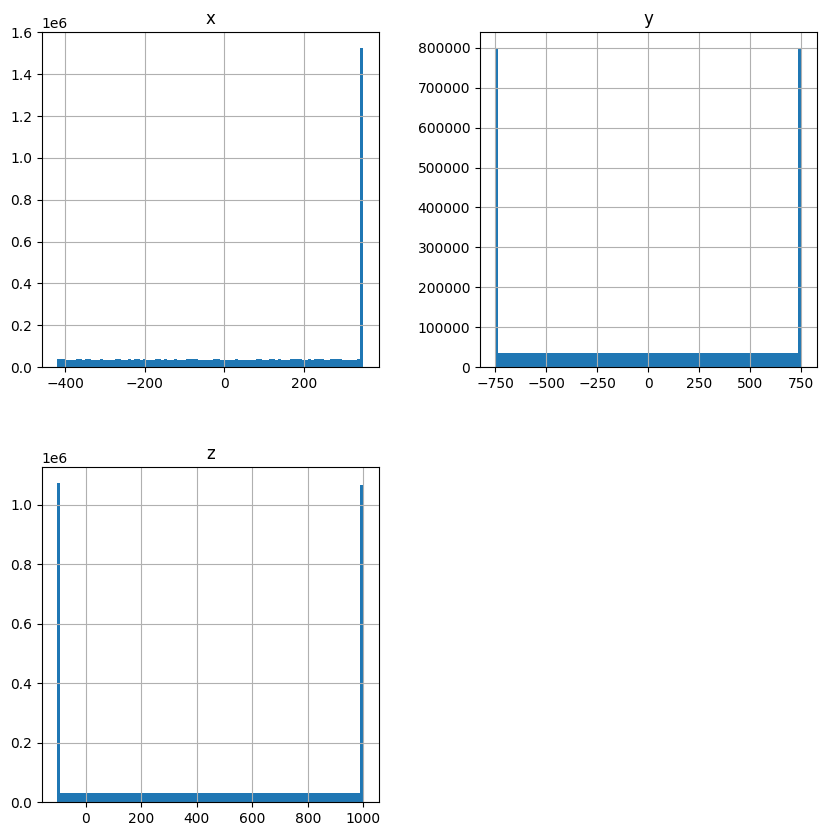

In [38]:
bkg_gammas = mct.query('generator_name == "CavernwallGammasAtLAr1x8x6"')
bkg_gammas[['x', 'y', 'z']].hist(bins=100, figsize=(10,10))